<a href="https://colab.research.google.com/github/DaniJonesOcean/etc-impacts-great-lakes/blob/main/notebooks/Extratropical_cyclone_impacts_on_the_Great_Lakes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports and Setup

In [1]:
# ------------------------------
# 1. Imports and Setup
# ------------------------------
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, FunctionTransformer, MinMaxScaler, RobustScaler
import joblib

# Ensure we can import from src
sys.path.append("../")
import importlib
import src.pipeline
importlib.reload(src.pipeline)
from src.pipeline import (
    add_season,
    clean_teleconnections,
    build_transformer,
    build_impact_transformer
)

# Paths
DATA_DIR = "../data"
PROCESSED_DIR = "../processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [2]:
# ------------------------------
# 2. Data Loading and Sanity Checks
# ------------------------------
df_era5 = pd.read_csv(os.path.join(DATA_DIR, "era5_etc.csv"))
df_cfsr = pd.read_csv(os.path.join(DATA_DIR, "cfsr_etc.csv"))

print("ERA5 shape:", df_era5.shape)
print("CFSR shape:", df_cfsr.shape)

# Select key variables to examine
key_vars = ['min_p_cent', 'max_p_grad', 'max_radius', 'max_uv',
            'fraction_of_time_in_GLR', 'maturity_glr0_minus_genesis_ratio']

print("\nERA5 Summary:")
display(df_era5[key_vars].describe())
print("\nCFSR Summary:")
display(df_cfsr[key_vars].describe())

ERA5 shape: (6136, 92)
CFSR shape: (3386, 82)

ERA5 Summary:


,min_p_cent,max_p_grad,max_radius,max_uv,fraction_of_time_in_GLR,maturity_glr0_minus_genesis_ratio
count,6136.000000,6136.000000,6136.000000,6136.000000,6136.000000,6136.000000
mean,987.208117,23.937711,1004.338056,107.322702,0.267445,0.264470
std,14.617619,9.923363,413.263217,26.783662,0.243401,0.275026
min,912.387459,8.254450,250.334294,26.424395,0.000000,0.000000
25%,978.938736,16.182580,693.825600,88.093280,0.083333,0.000000
50%,990.359349,21.861112,966.817911,109.310097,0.200000,0.181818
75%,997.982710,29.998305,1273.436163,129.009322,0.400000,0.428571
max,1021.648576,71.210767,3616.098744,222.052990,1.000000,1.000000



CFSR Summary:


,min_p_cent,max_p_grad,max_radius,max_uv,fraction_of_time_in_GLR,maturity_glr0_minus_genesis_ratio
count,3318.000000,3386.000000,3386.000000,3386.000000,3386.000000,3386.000000
mean,998.715114,16.141615,1024.543924,106.356429,0.256474,0.273293
std,8.375467,6.076501,408.781027,27.755806,0.233595,0.278045
min,957.616172,7.500833,250.731335,27.280463,-0.600000,-0.166667
25%,993.792852,11.517613,718.372935,86.096260,0.085714,0.000000
50%,999.659375,14.919219,990.349583,109.679214,0.192308,0.191392
75%,1004.516387,19.375731,1301.463182,128.297991,0.375000,0.444444
max,1022.841953,44.551383,3234.263229,194.783500,1.000000,1.000000


In [3]:
# ------------------------------
# 3. Data Cleaning
# ------------------------------

# Remove duplicated columns
print("Removing duplicate columns if present...")
df_era5 = df_era5.loc[:, ~df_era5.columns.duplicated()]
df_cfsr = df_cfsr.loc[:, ~df_cfsr.columns.duplicated()]

# Apply season and clean teleconnections
for df in [df_era5, df_cfsr]:
    add_season(df)
    clean_teleconnections(df)

# Remove invalid CFSR values
df_cfsr = df_cfsr[
    (df_cfsr['fraction_of_time_in_GLR'] >= 0) &
    (df_cfsr['maturity_glr0_minus_genesis_ratio'] >= 0)
].copy()

Removing duplicate columns if present...


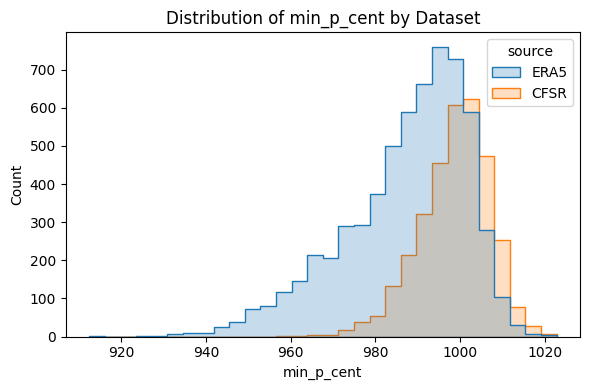

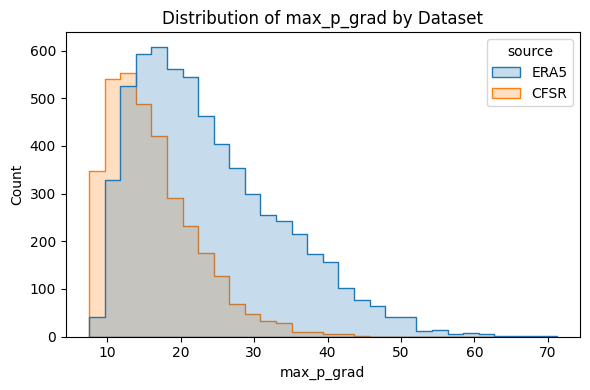

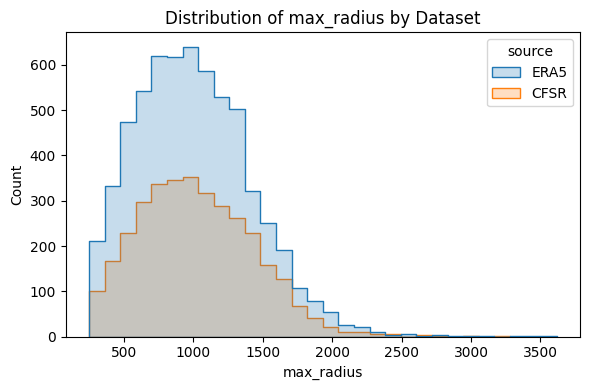

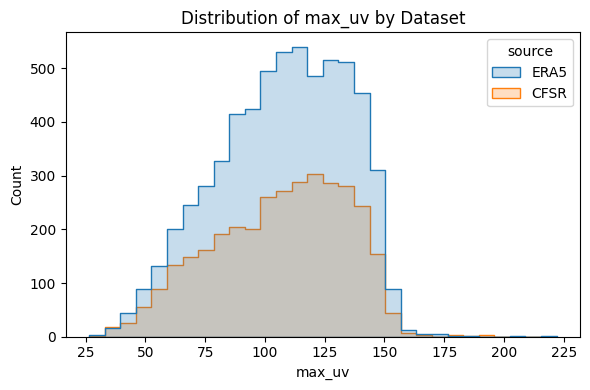

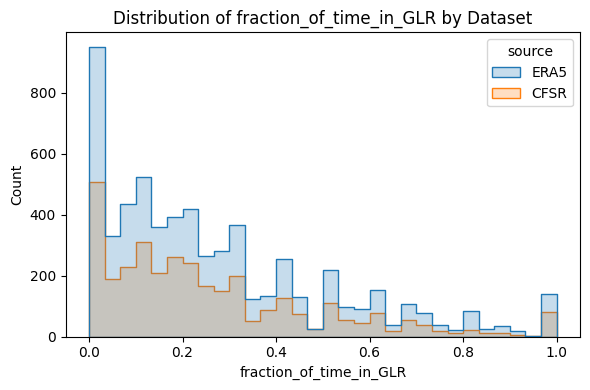

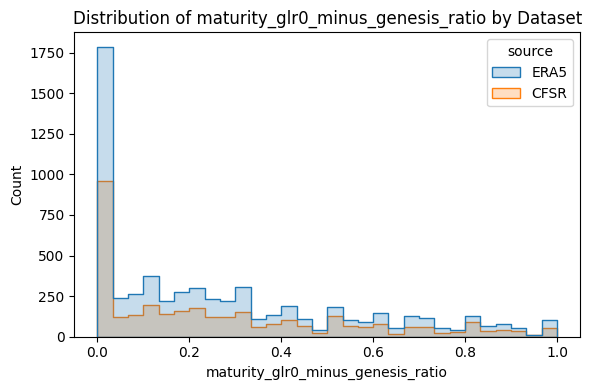

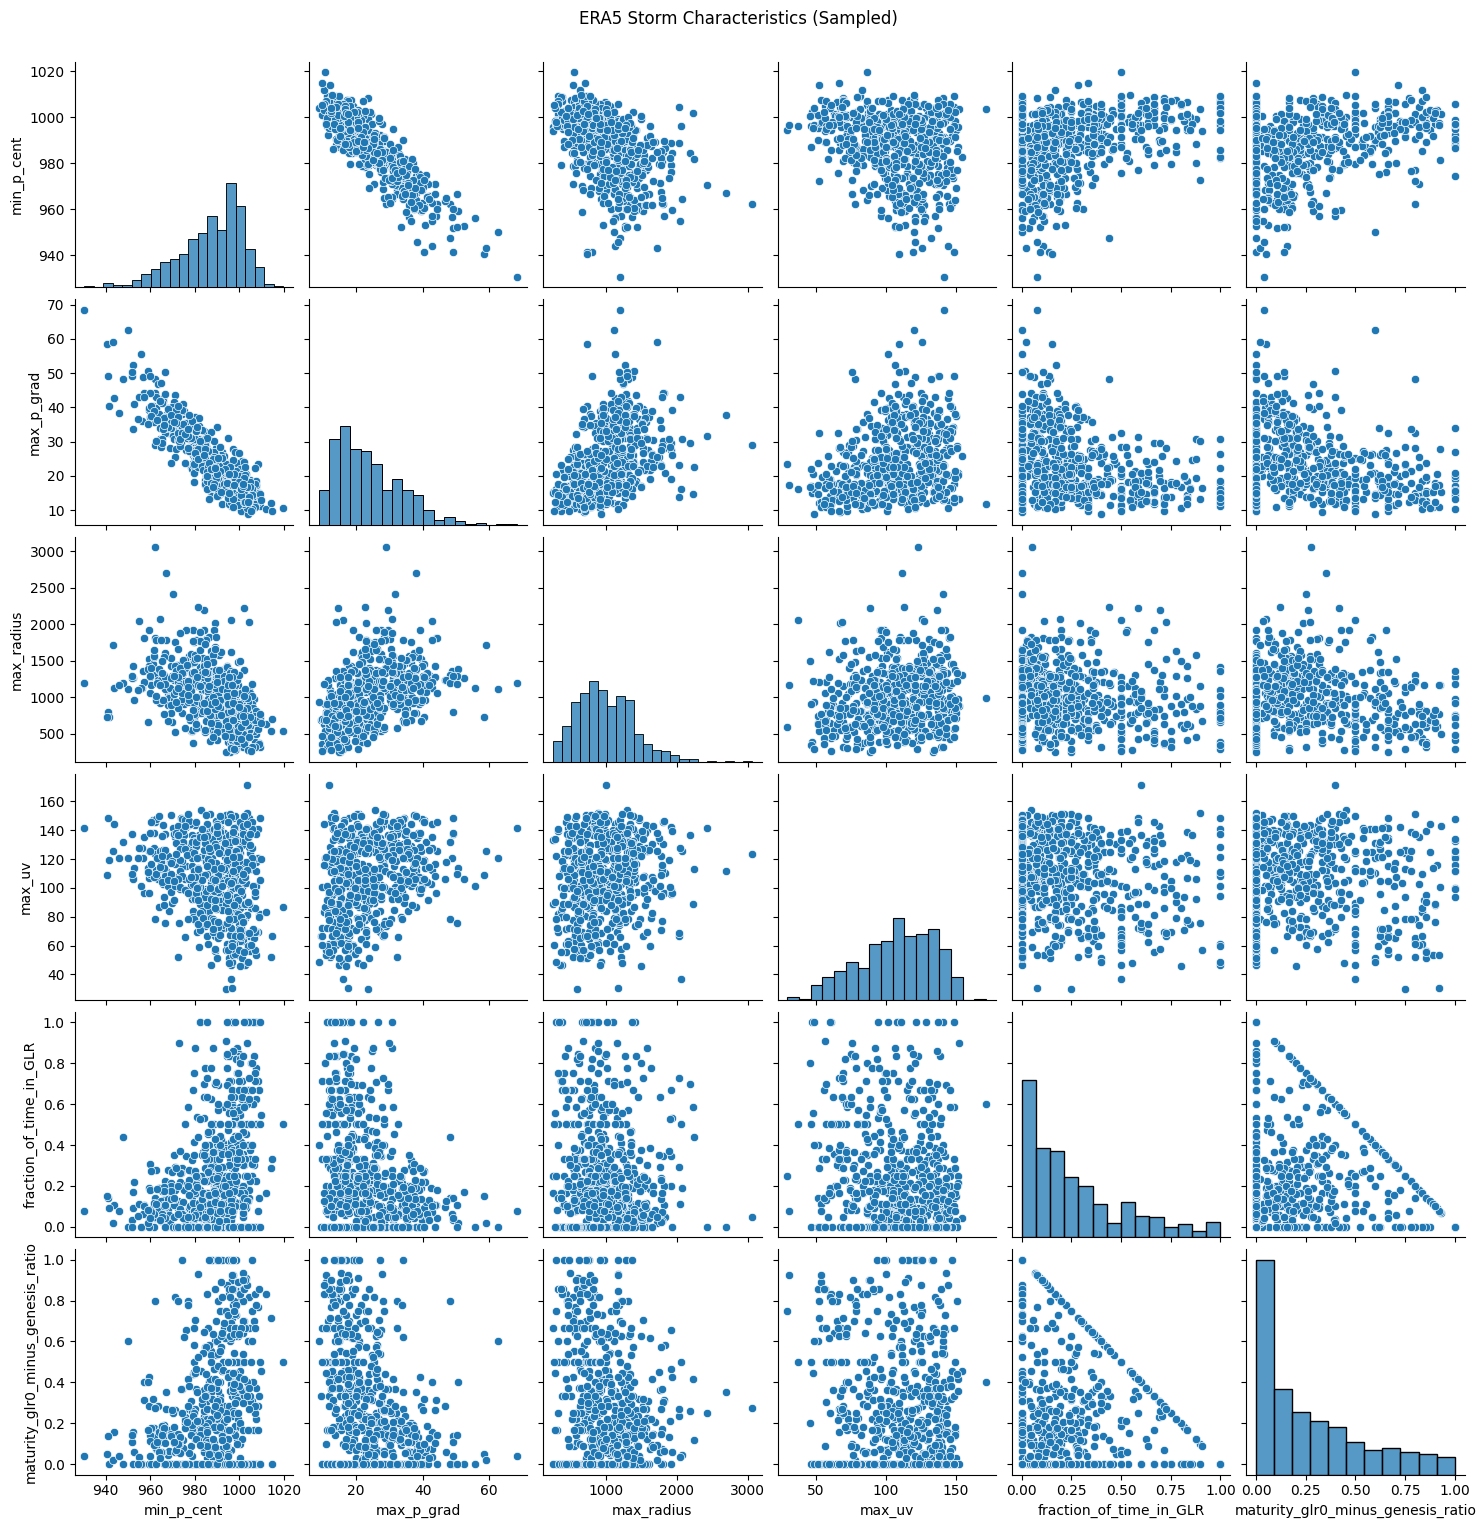

In [4]:
# ------------------------------
# 4a. Storm Property Visualizations
# ------------------------------
storm_characteristics = [
    'min_p_cent', 'max_p_grad', 'max_radius', 'max_uv',
    'fraction_of_time_in_GLR', 'maturity_glr0_minus_genesis_ratio']

# Add 'source' column for comparison
df_era5['source'] = 'ERA5'
df_cfsr['source'] = 'CFSR'
df_all = pd.concat([df_era5, df_cfsr], ignore_index=True)

# Histograms
for var in storm_characteristics:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_all, x=var, hue='source', bins=30, element='step', stat='count')
    plt.title(f"Distribution of {var} by Dataset")
    plt.tight_layout()
    plt.show()

# Pairplot (ERA5 only)
sns.pairplot(df_era5[storm_characteristics].sample(frac=0.1, random_state=42), corner=False)
plt.suptitle("ERA5 Storm Characteristics (Sampled)", y=1.02)
plt.show()

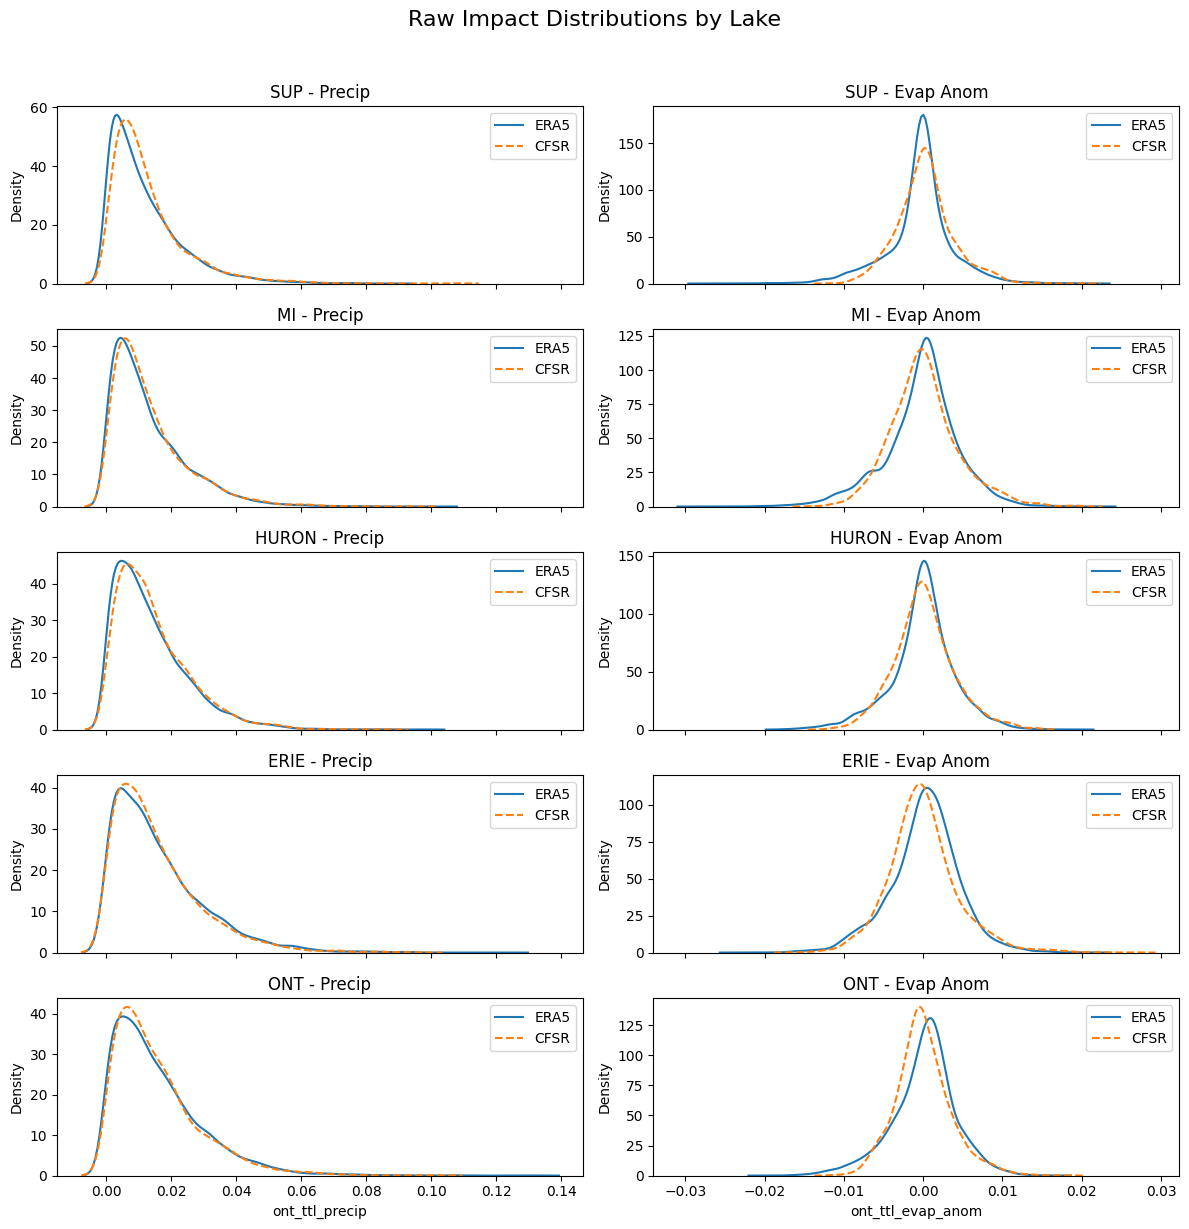

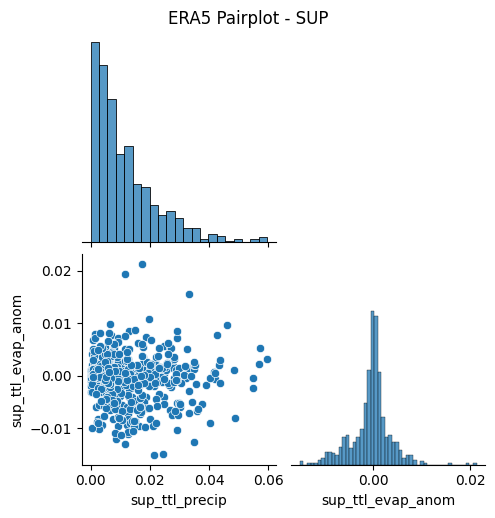

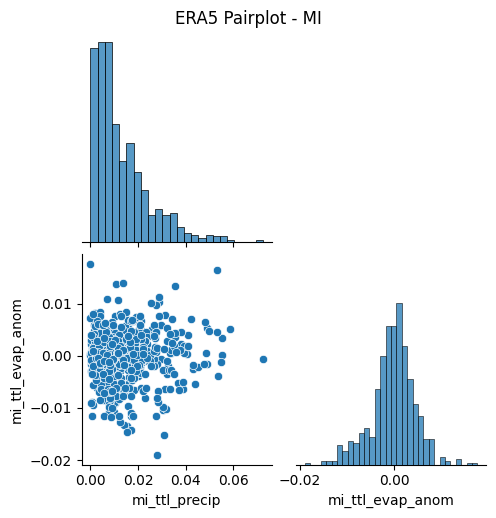

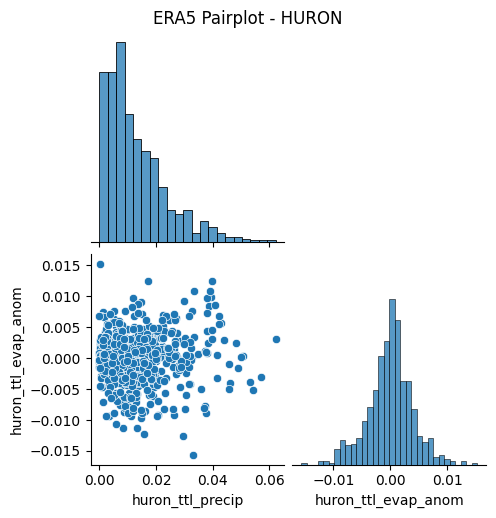

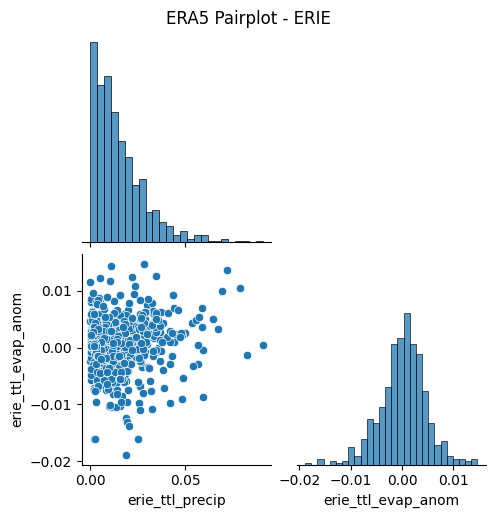

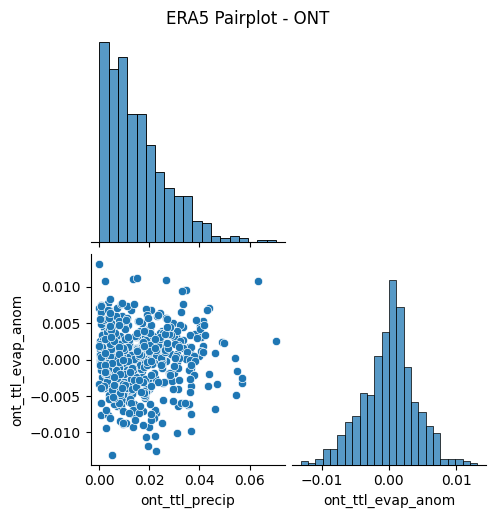

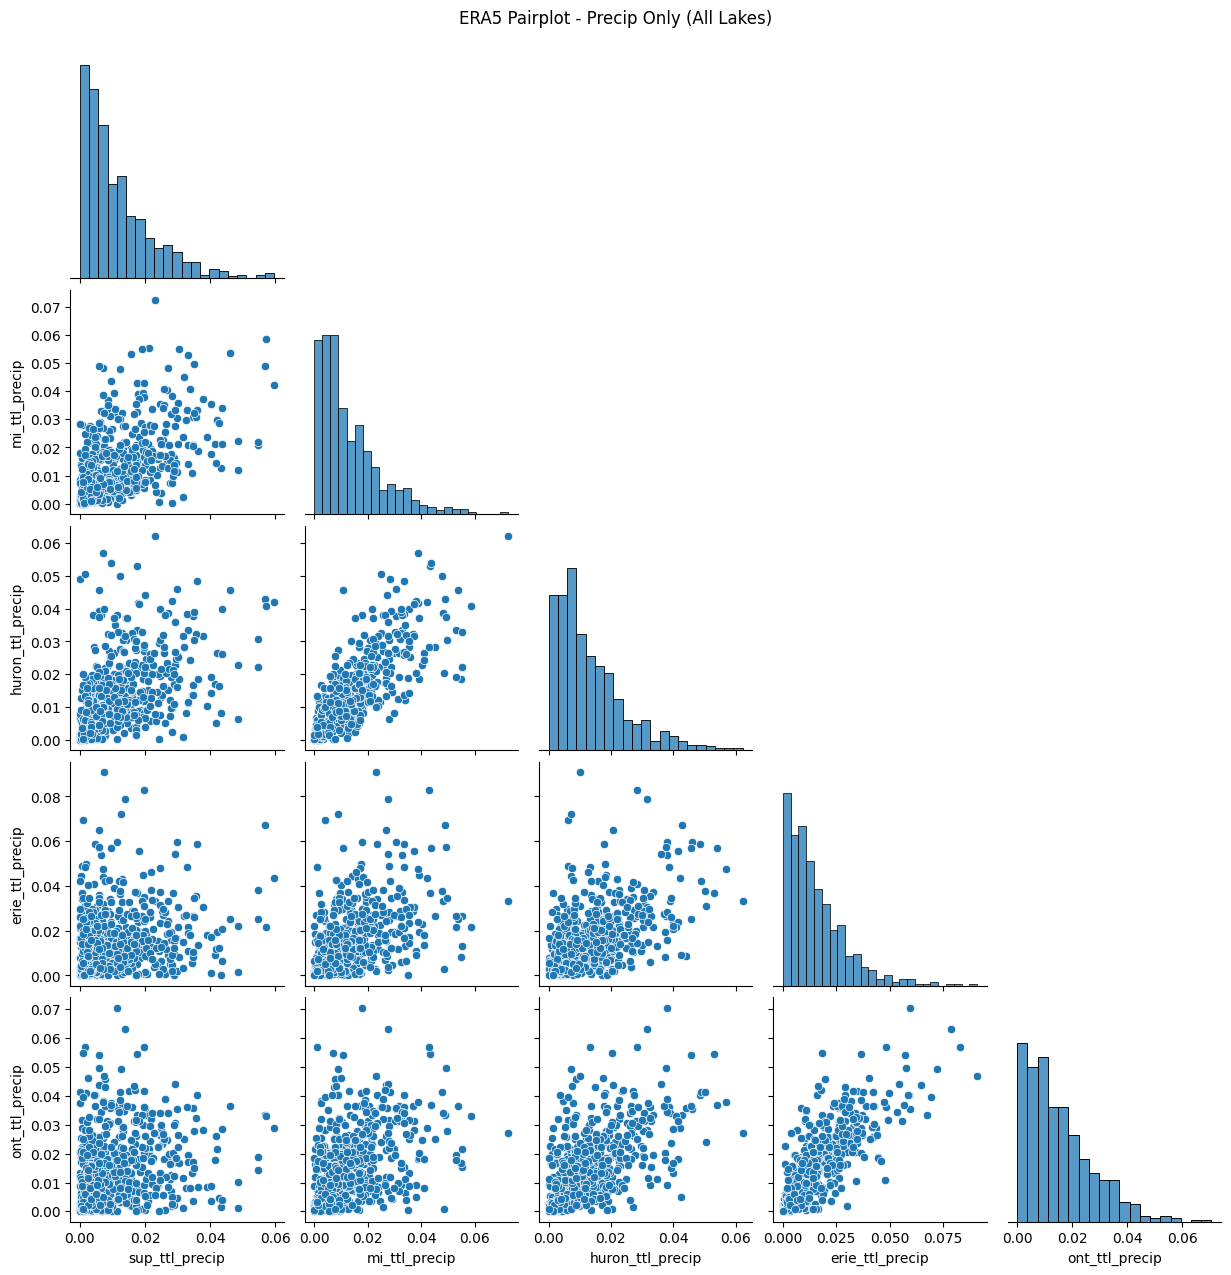

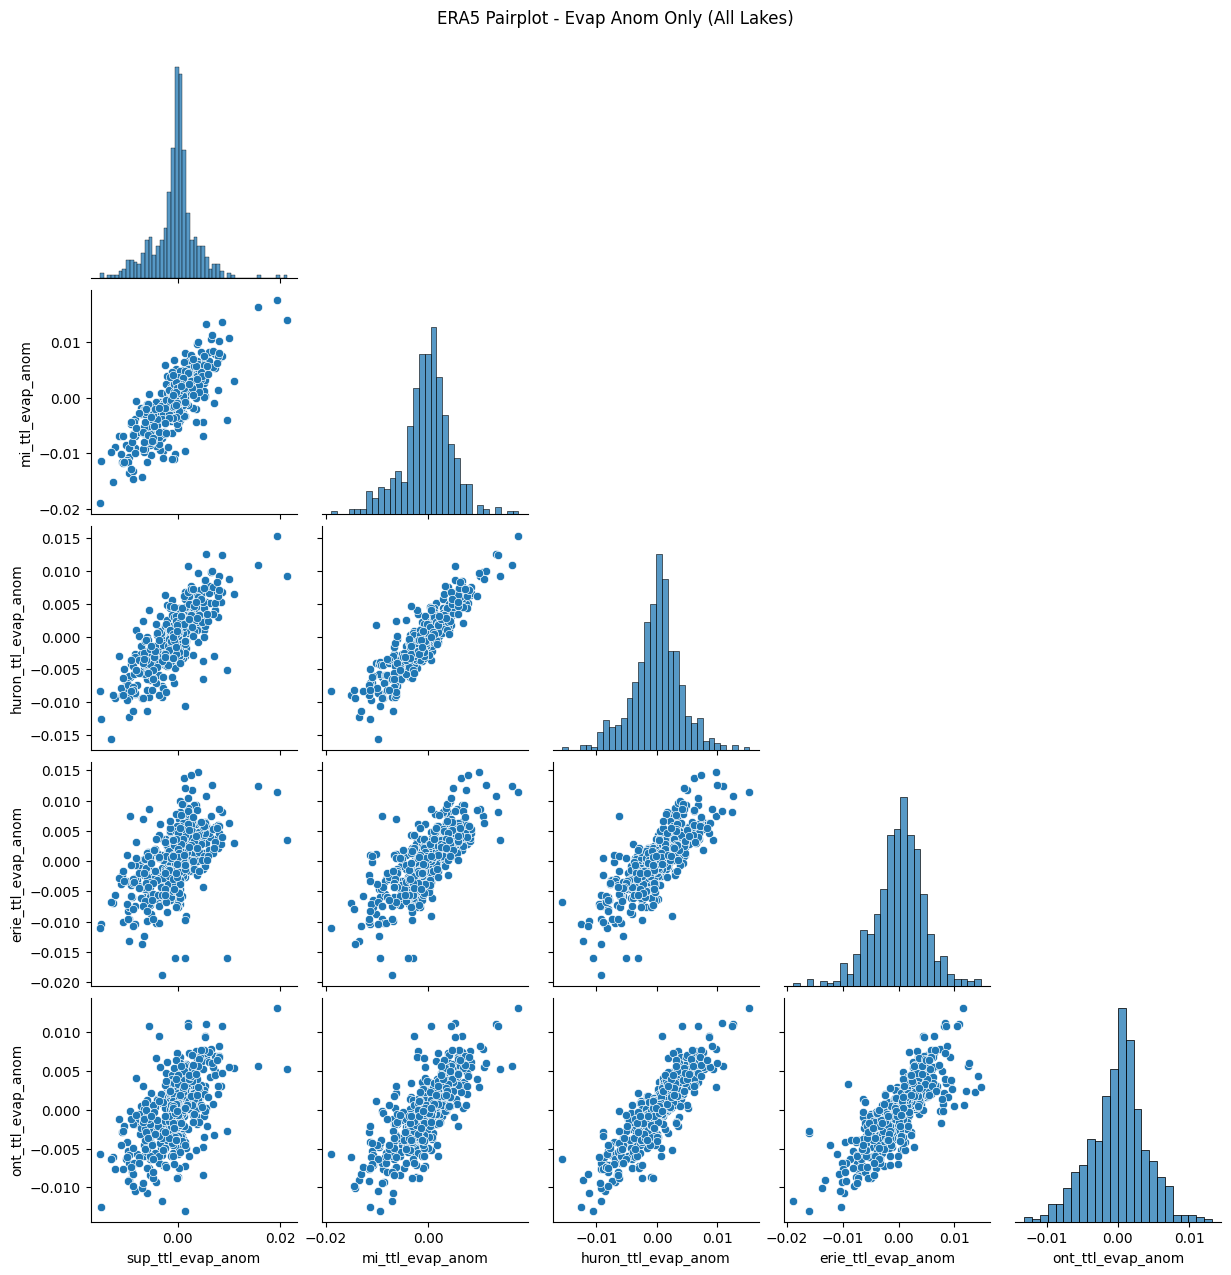

In [ ]:
# ------------------------------
# 4b. Impact Variable Visualizations
# ------------------------------
precip_vars = [
    'sup_ttl_precip', 'mi_ttl_precip', 'huron_ttl_precip', 'erie_ttl_precip', 'ont_ttl_precip']
evap_anom_vars = [
    'sup_ttl_evap_anom', 'mi_ttl_evap_anom', 'huron_ttl_evap_anom', 'erie_ttl_evap_anom', 'ont_ttl_evap_anom']
lakes = ['sup', 'mi', 'huron', 'erie', 'ont']

# Visualize raw impacts separately for precip and evap anoms
fig, axs = plt.subplots(len(lakes), 2, figsize=(12, 12), sharex='col')
fig.suptitle("Raw Impact Distributions by Lake", fontsize=16, y=1.02)

for i, lake in enumerate(lakes):
    # Precipitation
    precip_col = f"{lake}_ttl_precip"
    sns.kdeplot(df_era5[precip_col], ax=axs[i, 0], label="ERA5", linestyle='-')
    sns.kdeplot(df_cfsr[precip_col], ax=axs[i, 0], label="CFSR", linestyle='--')
    axs[i, 0].set_title(f"{lake.upper()} - Precip")
    axs[i, 0].legend()

    # Evaporation anomaly
    evap_col = f"{lake}_ttl_evap_anom"
    sns.kdeplot(df_era5[evap_col], ax=axs[i, 1], label="ERA5", linestyle='-')
    sns.kdeplot(df_cfsr[evap_col], ax=axs[i, 1], label="CFSR", linestyle='--')
    axs[i, 1].set_title(f"{lake.upper()} - Evap Anom")
    axs[i, 1].legend()

plt.tight_layout()
plt.show()

# Pairplots: Precip vs Evap by lake
for lake in lakes:
    pair_cols = [f"{lake}_ttl_precip", f"{lake}_ttl_evap_anom"]
    sns.pairplot(df_era5[pair_cols].sample(frac=0.1, random_state=42), corner=True)
    plt.suptitle(f"ERA5 Pairplot - {lake.upper()}", y=1.02)
    plt.show()

# Pairplots: Precip only and Evap only (all lakes)
sns.pairplot(df_era5[precip_vars].sample(frac=0.1, random_state=42), corner=False)
plt.suptitle("ERA5 Pairplot - Precip Only (All Lakes)", y=1.02)
plt.show()

sns.pairplot(df_era5[evap_anom_vars].sample(frac=0.1, random_state=42), corner=False)
plt.suptitle("ERA5 Pairplot - Evap Anom Only (All Lakes)", y=1.02)
plt.show()

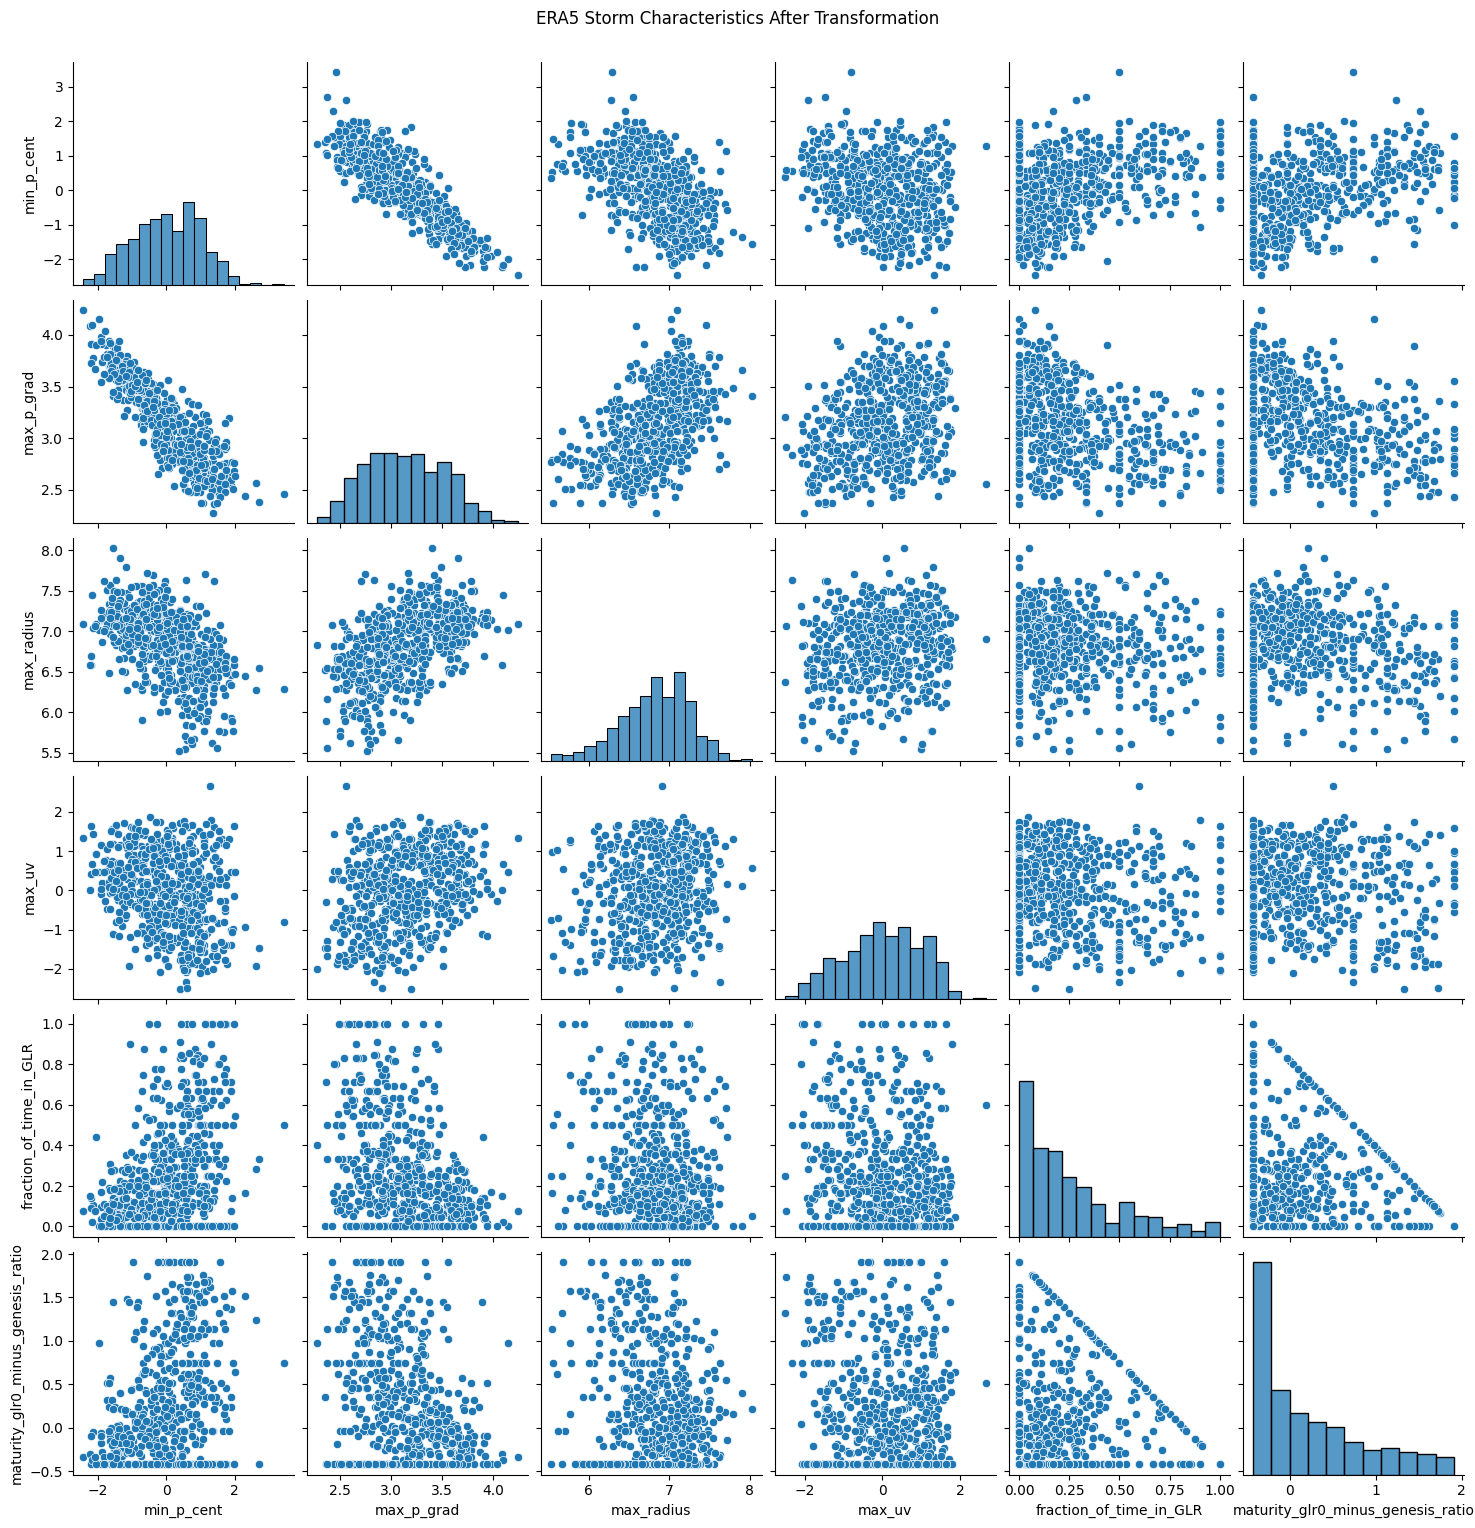

In [6]:
# ------------------------------
# 5a. Transform Storm Properties
# ------------------------------
preprocessor = build_transformer()
X_era5 = df_era5[storm_characteristics]
X_cfsr = df_cfsr[storm_characteristics]

X_era5_transformed = preprocessor.fit_transform(X_era5)
X_cfsr_transformed = preprocessor.transform(X_cfsr)

df_era5_transformed = pd.DataFrame(X_era5_transformed, columns=storm_characteristics, index=df_era5.index)
df_cfsr_transformed = pd.DataFrame(X_cfsr_transformed, columns=storm_characteristics, index=df_cfsr.index)

sns.pairplot(df_era5_transformed.sample(frac=0.1, random_state=42), corner=False)
plt.suptitle("ERA5 Storm Characteristics After Transformation", y=1.02)
plt.show()

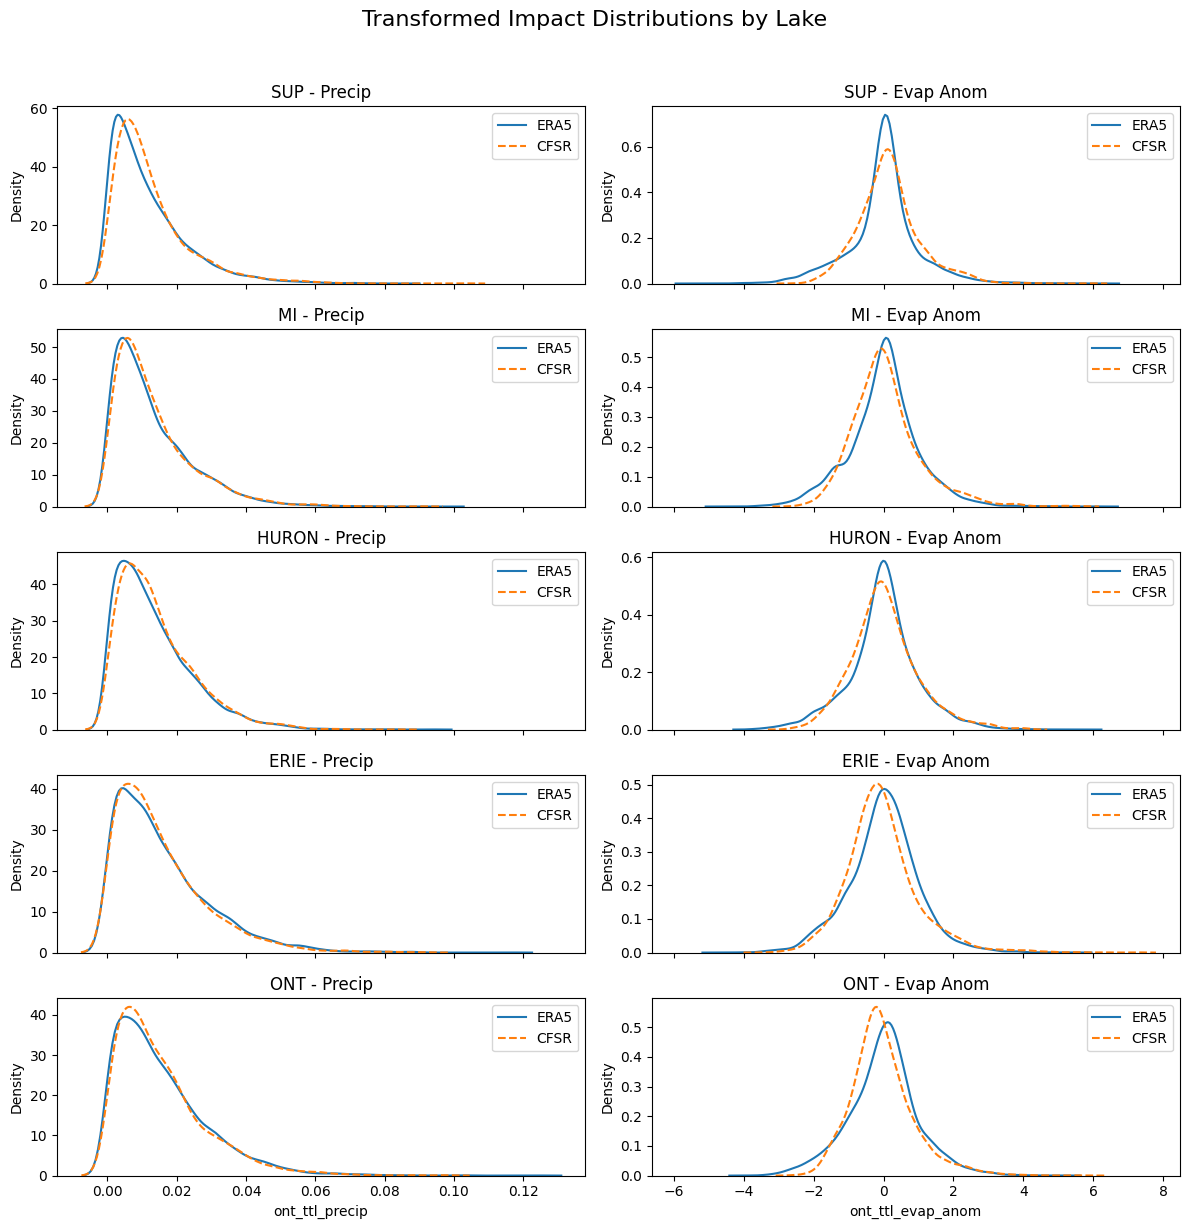

In [15]:
# ------------------------------
# 5b. Transform Impacts
# ------------------------------
impact_transformer = build_impact_transformer()
impact_vars = precip_vars + evap_anom_vars

X_era5_impact = df_era5[impact_vars]
X_cfsr_impact = df_cfsr[impact_vars]

X_era5_impact_trans = impact_transformer.fit_transform(X_era5_impact)
X_cfsr_impact_trans = impact_transformer.transform(X_cfsr_impact)

df_era5_impact_trans = pd.DataFrame(X_era5_impact_trans, columns=impact_vars, index=df_era5.index)
df_cfsr_impact_trans = pd.DataFrame(X_cfsr_impact_trans, columns=impact_vars, index=df_cfsr.index)

# Visualize transformed impacts separately for precip and evap anoms
fig, axs = plt.subplots(len(lakes), 2, figsize=(12, 12), sharex='col')
fig.suptitle("Transformed Impact Distributions by Lake", fontsize=16, y=1.02)

for i, lake in enumerate(lakes):
    # Precipitation
    precip_col = f"{lake}_ttl_precip"
    sns.kdeplot(df_era5_impact_trans[precip_col], ax=axs[i, 0], label="ERA5", linestyle='-')
    sns.kdeplot(df_cfsr_impact_trans[precip_col], ax=axs[i, 0], label="CFSR", linestyle='--')
    axs[i, 0].set_title(f"{lake.upper()} - Precip")
    axs[i, 0].legend()

    # Evaporation anomaly
    evap_col = f"{lake}_ttl_evap_anom"
    sns.kdeplot(df_era5_impact_trans[evap_col], ax=axs[i, 1], label="ERA5", linestyle='-')
    sns.kdeplot(df_cfsr_impact_trans[evap_col], ax=axs[i, 1], label="CFSR", linestyle='--')
    axs[i, 1].set_title(f"{lake.upper()} - Evap Anom")
    axs[i, 1].legend()

plt.tight_layout()
plt.show()

In [8]:
from src.pipeline import build_impact_transformer

transformer = build_impact_transformer()
print(transformer)


ColumnTransformer(transformers=[('precip',
                                 FunctionTransformer(func=<ufunc 'log1p'>),
                                 ['sup_ttl_precip', 'mi_ttl_precip',
                                  'huron_ttl_precip', 'erie_ttl_precip',
                                  'ont_ttl_precip']),
                                ('evap_anom', PowerTransformer(),
                                 ['sup_ttl_evap_anom', 'mi_ttl_evap_anom',
                                  'huron_ttl_evap_anom', 'erie_ttl_evap_anom',
                                  'ont_ttl_evap_anom'])])


In [11]:
# ------------------------------
# 6. Save All Outputs
# ------------------------------
df_era5_impact_trans.to_csv(os.path.join(PROCESSED_DIR, "df_era5_impact_transformed.csv"), index=False)
df_cfsr_impact_trans.to_csv(os.path.join(PROCESSED_DIR, "df_cfsr_impact_transformed.csv"), index=False)

joblib.dump(impact_transformer, os.path.join(PROCESSED_DIR, "impact_transformer.joblib"))

# Merge transformed storm properties with passthrough data
pass_through_cols = impact_vars + ['lat_gen', 'lon_gen', 'year', 'month', 'season'] + [
    'amo_unsmoothed_value', 'ao_value', 'ea_wr_value', 'enso_best_value', 'ep_np_value',
    'ipo_value', 'nao_value', 'pdo_value', 'pna_value', 'pol_value', 'qbo_value', 'tnh_value', 'wp_value']

era5_final = pd.concat([df_era5_transformed, df_era5[pass_through_cols]], axis=1)
cfsr_final = pd.concat([df_cfsr_transformed, df_cfsr[pass_through_cols]], axis=1)

era5_final.to_csv(os.path.join(PROCESSED_DIR, "df_era5_transformed.csv"), index=False)
cfsr_final.to_csv(os.path.join(PROCESSED_DIR, "df_cfsr_transformed.csv"), index=False)

joblib.dump(preprocessor, os.path.join(PROCESSED_DIR, "storm_preprocessor.joblib"))

print("✅ Cleaned, transformed, and saved all datasets.")

✅ Cleaned, transformed, and saved all datasets.
